<a href="https://colab.research.google.com/github/Dipto1971/Statistical-Analysis-Data-Science/blob/main/Assignment/EDA_Automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Automating Univariate Statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def univariate(df):
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  import seaborn as sns

  output_df = pd.DataFrame(columns = ['type', 'count', 'missing', 'unique', 'mode', 'min', 'Q1',
                                      'median', 'Q3', 'max', 'mean', 'std', 'skewness', 'kurtosis'])

  for col in df:
    # Calculate metrics that apply to all dtypes
    dtype = df[col].dtype
    count = df[col].count()
    missing = df[col].isnull().sum()
    unique = df[col].nunique()
    mode = df[col].mode()[0]

    if pd.api.types.is_numeric_dtype(df[col]):
      min = df[col].min()
      Q1 = df[col].quantile(0.25)
      median = df[col].median()
      Q3 = df[col].quantile(0.75)
      max = df[col].max()
      mean = df[col].mean()
      std = df[col].std()
      skewness = df[col].skew()
      kurtosis = df[col].kurtosis()

      output_df.loc[col] = [dtype, count, missing, unique, mode, min, Q1,
                            median, Q3, max, mean, std, skewness, kurtosis ]

      sns.histplot(data=df, x=col)
      plt.show()
    else:
      output_df.loc[col] = [dtype, count, missing, unique, mode, '-', '-',
                            '-', '-', '-', '-', '-', '-', '-']
      sns.countplot(data=df, x=col)
      plt.show()
  # output_df.to_csv('EDA.csv')
  return output_df

In [3]:
def bivariate_stats(df, label, roundto=4):
  import pandas as pd
  from scipy import stats

  output_df = pd.DataFrame(columns=['p-value', 'r-value', 'y = m(x) + b', 'F', 'X2'])

  for feature in df:
    # There Might be missing values for which analysis can come up with inaccuracy
    if feature != label:
     if pd.api.types.is_numeric_dtype(df[feature]) and pd.api.types.is_numeric_dtype(df[label]):
       # Process N2N relationships
       m, b, r, p, err = stats.linregress(df[feature], df[label])
       output_df.loc[feature] = [round(p, roundto), round(r, roundto), f"y={round(m, roundto)}x+{round(b, roundto)}", '-', '-']
     elif not pd.api.types.is_numeric_dtype(df[feature]) and not pd.api.types.is_numeric_dtype(df[label]):
       #  Process C2C relationships
       contingency_table = pd.crosstab(df[feature], df[label])
       chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

       output_df.loc[feature] = [round(p, roundto), '-', '-', '-', round(chi2, roundto)]
     else:
       # Process C2N & N2C relationships
       if pd.api.types.is_numeric_dtype(df[feature]):
        num = feature
        cat = label
       else:
        num = label
        cat = feature

       groups = df[cat].unique()
       group_lists = []
       for g in groups:
        group_lists.append(df[df[cat] == g][num])

       f, p = stats.f_oneway(*group_lists) # same as (group_lists[0], group_lists[1], ..., group_lists[n])

       output_df.loc[feature] = [round(p, roundto), '-', '-', round(f, roundto), '-']
  # return output_df.sort_values(by=['r-value'], ascending=False)
  #From strongest correlation to weakest correlation

  return output_df




C:\Users\dipto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 48.2k/48.2k [00:00<00:00, 386kB/s]

Extracting files...


100%|██████████| 16.0k/16.0k [00:00<00:00, 215kB/s]

Extracting files...


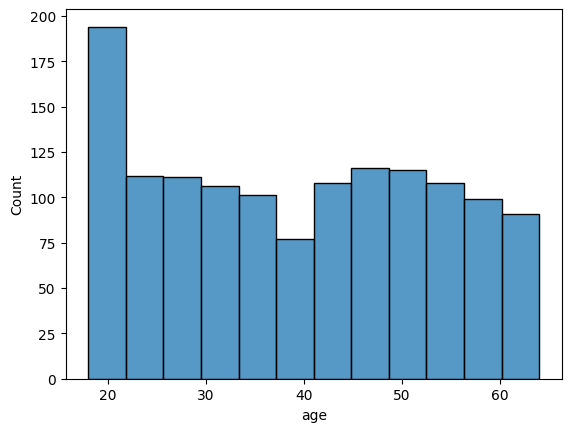

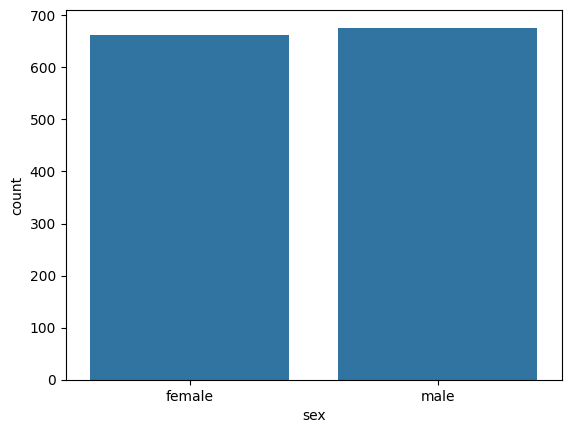

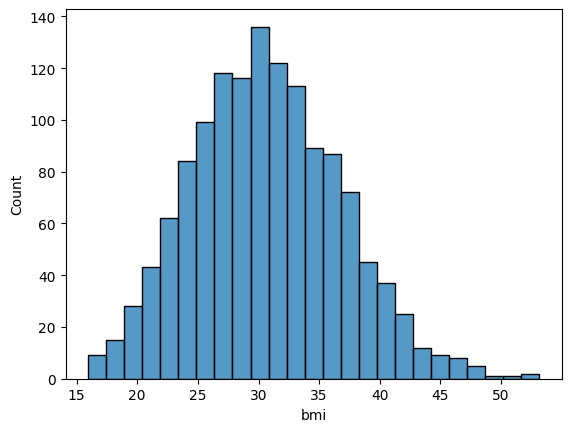

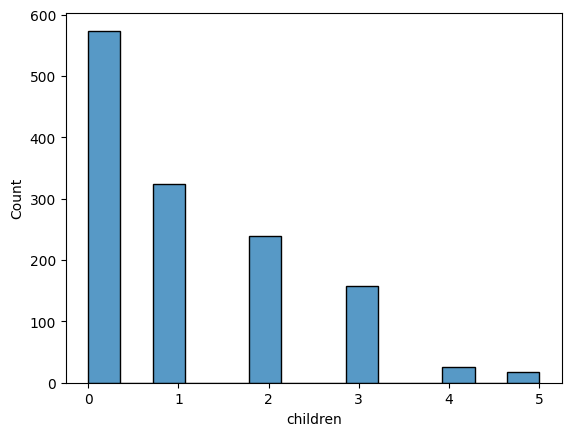

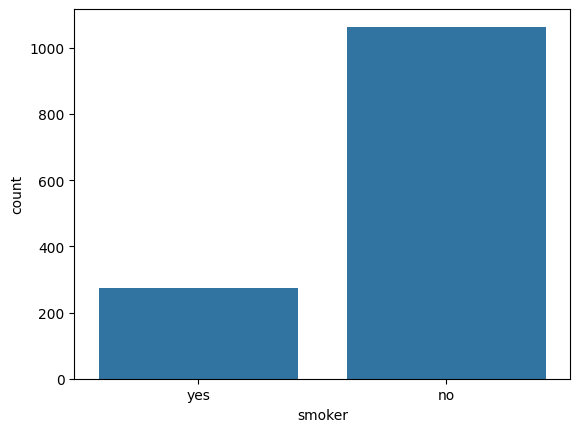

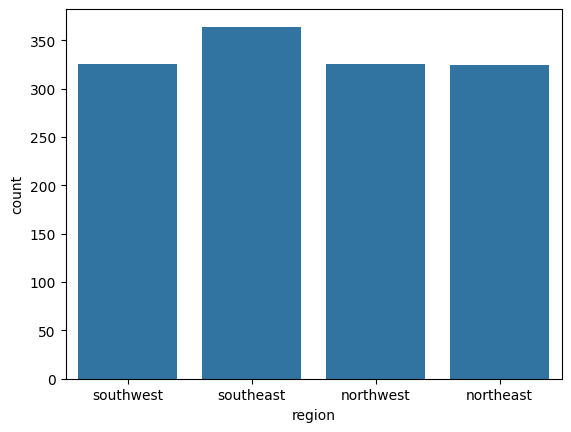

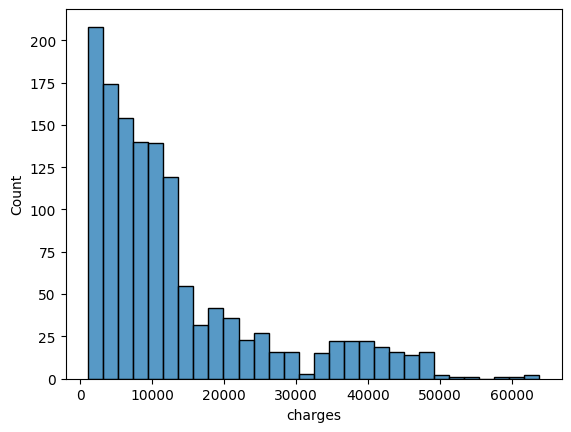

,type,count,missing,unique,mode,min,Q1,median,Q3,max,mean,std,skewness,kurtosis
age,int64,1338,0,47,18,18,27.0,39.0,51.0,64,39.207025,14.04996,0.055673,-1.245088
sex,object,1338,0,2,male,-,-,-,-,-,-,-,-,-
bmi,float64,1338,0,548,32.3,15.96,26.29625,30.4,34.69375,53.13,30.663397,6.098187,0.284047,-0.050732
children,int64,1338,0,6,0,0,0.0,1.0,2.0,5,1.094918,1.205493,0.93838,0.202454
smoker,object,1338,0,2,no,-,-,-,-,-,-,-,-,-
region,object,1338,0,4,southeast,-,-,-,-,-,-,-,-,-
charges,float64,1338,0,1337,1639.5631,1121.8739,4740.28715,9382.033,16639.912515,63770.42801,13270.422265,12110.011237,1.51588,1.606299


In [5]:
import kagglehub
import pandas as pd
# Download latest version
mental_heath_data = kagglehub.dataset_download("shakilh/bangladeshi-university-students-mental-health")
health_insurance_data = kagglehub.dataset_download("teertha/ushealthinsurancedataset")

df_insurance = pd.read_csv(health_insurance_data + "/insurance.csv")
# df = pd.read_csv(mental_heath_data + "/Raw Data.csv")

univariate(df_insurance)
# bivariate_stats(df_insurance, 'charges')

